# M3T over New York City

A worked example of the Python port: build a gridded methane inventory for the
NYC metro area and see how the answer moves as you change the knobs.

Four experiments:

1. **Resolution** — the same inventory at ~1 km, ~2 km and ~10 km. The map gets
   blockier; the *total mass must not move*.
2. **Wetlands** — Wetcharts (process-model ensemble) vs SOCCR1 vs SOCCR2
   (land-cover × emission factor).
3. **Disaggregation** — Vulcan vs ACES as the CO₂ proxy, and splitting emissions
   from state totals vs one domain total.
4. **Mass conservation** — the shipped default vs the R-compatible gridding,
   which inflates the total by ~1.4%.

**Requires the M3T companion data** (the Zenodo archive: Vulcan, ACES, NWI,
Wetcharts, Tigerlines, GHGRP, DMR). Point `M3T_DATA` at it.

In [1]:
from __future__ import annotations

import os
import shutil
import time
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap, LogNorm

from m3t import geo
from m3t.config import Config
from m3t.inventory import ch4_inventory_build

warnings.filterwarnings("ignore")

DATA = Path(os.environ.get("M3T_DATA", "/Volumes/Expansion/M3T_Processed"))
CACHE = Path("nb_cache")          # GEPA download lands here (gitignored)
RUNS = Path("nb_runs")            # one subdirectory per configuration
INVENTORY_YEAR = 2019

assert DATA.exists(), f"companion data not found at {DATA} -- set M3T_DATA"
CACHE.mkdir(exist_ok=True)
RUNS.mkdir(exist_ok=True)
print("companion data:", DATA)

companion data: /Volumes/Expansion/M3T_Processed


## Plot styling

Flux is a **magnitude**, so the maps use a single-hue sequential ramp (light →
dark), never a rainbow. Every map in a figure shares one log colour scale, so the
panels are actually comparable — that is the whole point of the exercise.

Config variants are an **identity**, so they get categorical hues assigned in a
fixed order (never cycled, never reassigned when the set changes).

In [2]:
# sequential ramp for magnitude (blue, light -> dark)
FLUX_CMAP = LinearSegmentedColormap.from_list(
    "m3t_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)
FLUX_CMAP.set_bad("#f2f2ef")  # cells outside the domain

# categorical hues, in fixed order
SERIES = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e34948", "#e87ba4"]

INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#e6e6e1"
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_MUTED,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})

## Domain: the NYC metro

A bounding box over the five boroughs plus northern New Jersey and the near
suburbs. The orchestrator clips the state Tigerlines to it, which is what tells
every state-resolved sector (septic, stationary combustion, NG distribution,
wetlands) which states it is working in.

In [3]:
NYC_BBOX = (-74.35, 40.45, -73.60, 41.05)  # xmin, ymin, xmax, ymax

states_all = gpd.read_file(DATA / "combined_state_tigerlines.gpkg", layer=str(INVENTORY_YEAR))
states_all = states_all.to_crs("epsg:4326")

bbox_gdf = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries.from_wkt([
        "POLYGON(({0} {1},{2} {1},{2} {3},{0} {3},{0} {1}))".format(
            NYC_BBOX[0], NYC_BBOX[1], NYC_BBOX[2], NYC_BBOX[3])
    ]), crs="epsg:4326",
)
domain_states = gpd.clip(states_all, bbox_gdf)
domain_states = domain_states[domain_states.geometry.area > 0]
print("states in the domain:", sorted(domain_states.STUSPS))

states in the domain: ['CT', 'NJ', 'NY']


In [4]:
def res_km(res_deg: float) -> float:
    """Effective cell size in km for a given degree resolution at this latitude."""
    tmpl = geo.make_grid(NYC_BBOX, res_deg, "epsg:4326")
    return float(np.sqrt(geo.cell_area(tmpl, unit="km").values.mean()))


RESOLUTIONS = {0.01: None, 0.02: None, 0.1: None}
RESOLUTIONS = {r: res_km(r) for r in RESOLUTIONS}
for r, km in RESOLUTIONS.items():
    tmpl = geo.make_grid(NYC_BBOX, r, "epsg:4326")
    print(f"{r:>5}deg -> {km:4.2f} km cells, grid {tmpl.shape[0]} x {tmpl.shape[1]}")

 0.01deg -> 0.97 km cells, grid 60 x 75
 0.02deg -> 1.94 km cells, grid 30 x 38
  0.1deg -> 9.68 km cells, grid 6 x 8


## Wiring the companion data

Rather than override every `Source_*` option, we symlink the companion files into
each run's `in/` directory. That way the run exercises the **default** `"M3T"`
data paths — the same code path a normal user hits.

In [5]:
GEPA_FILE = CACHE / "Express_Extension_Gridded_GHGI_Methane_v2_2019.nc"
if not GEPA_FILE.exists():
    from m3t.download import trycatch_downloader
    trycatch_downloader(
        "https://zenodo.org/api/records/8367082/files/"
        "Express_Extension_Gridded_GHGI_Methane_v2_2019.nc/content",
        output_location=GEPA_FILE, method="save",
    )
print("GEPA:", GEPA_FILE, f"({GEPA_FILE.stat().st_size/1e6:.1f} MB)")

_COMPANION = [
    "DMR_data.csv", "combined_wastewater_NLCD.tif", "Total_national_septic_area.csv",
    "wastewater_state_septic_area.csv", "processed_NWI_data", "Watersheds.gpkg",
    "combined_NLCD_downscaled_wetcharts.tif", "combined_county_tigerlines.gpkg",
    "Vulcan_v4.0", "ACES V2.0", "EIA",
]


def prepare_run_dir(tag: str) -> Path:
    """A fresh run directory whose in/ points at the companion data."""
    run = RUNS / tag
    if (run / "out").exists():
        shutil.rmtree(run / "out")
    (run / "in" / "GHGRP").mkdir(parents=True, exist_ok=True)
    (run / "in" / "NEI").mkdir(parents=True, exist_ok=True)
    for name in _COMPANION:
        link, target = run / "in" / name, DATA / name
        if target.exists() and not link.exists():
            link.symlink_to(target)
    for name in ("facility_data.csv", "Oil_and_gas_W.csv"):
        link, target = run / "in" / "GHGRP" / name, DATA / "GHGRP" / name
        if target.exists() and not link.exists():
            link.symlink_to(target)
    return run


def base_config() -> Config:
    cfg = Config()
    cfg.Source_Vulcan = "M3T"       # read the extracted tifs from in/Vulcan_v4.0
    cfg.Source_GEPA = str(GEPA_FILE)
    return cfg


def run(tag: str, res: float, cfg: Config) -> dict:
    """Run the inventory and return {sector: raster} plus timing."""
    t0 = time.time()
    ctx = ch4_inventory_build(
        run_directory=prepare_run_dir(tag),
        inventory_year=INVENTORY_YEAR,
        domain=NYC_BBOX,
        domain_res=res,
        domain_crs="epsg:4326",
        tigerlines=states_all,
        config=cfg,
    )
    out = {"ctx": ctx, "seconds": time.time() - t0, "template": ctx.domain_template}
    for key in ctx.shared["sectors_run"]:
        ds = xr.open_dataset(ctx.output_directory / f"{key}.nc")
        out[key] = ds["methane_emissions"]
    return out


def total_mass(da, template) -> float:
    """Total emissions on a flux raster, in mol/s (flux nmol/m2/s x area m2)."""
    area = geo.cell_area(template, unit="m").values
    return float(np.nansum(da.values * area)) * 1e-9

GEPA: nb_cache/Express_Extension_Gridded_GHGI_Methane_v2_2019.nc (3.0 MB)


## 1. Resolution: ~1 km, ~2 km, ~10 km

Same configuration, three grids. The spatial detail changes a lot; the **total
mass should not**, because the conservative regrid carries the emissions from
partially-covered fine pixels across rather than dropping or double-counting them.

In [6]:
res_runs = {}
for r, km in RESOLUTIONS.items():
    cfg = base_config()
    res_runs[r] = run(f"res_{r}", r, cfg)
    print(f"{km:4.2f} km  ->  {res_runs[r]['seconds']:5.1f}s, "
          f"sectors: {len(res_runs[r]['ctx'].shared['sectors_run'])}")

NEI is every 3 years and does not have an inventory for 2019. Using 2020 as the nearest available data.


Running sector: Municipal solid waste (landfills)
Running sector: Natural gas distribution


Running sector: Natural gas transmission
Running sector: Stationary combustion


Running sector: Wastewater


Running sector: Wetlands & inland waters


...

Running sector: Municipal solid waste (landfills)
Running sector: Natural gas distribution


Running sector: Natural gas transmission
Running sector: Stationary combustion


Running sector: Wastewater


Running sector: Wetlands & inland waters


Running sector: Remaining sectors (gridded EPA)
Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/res_0.1/out/M3T_total.nc
9.68 km  ->   10.5s, sectors: 7


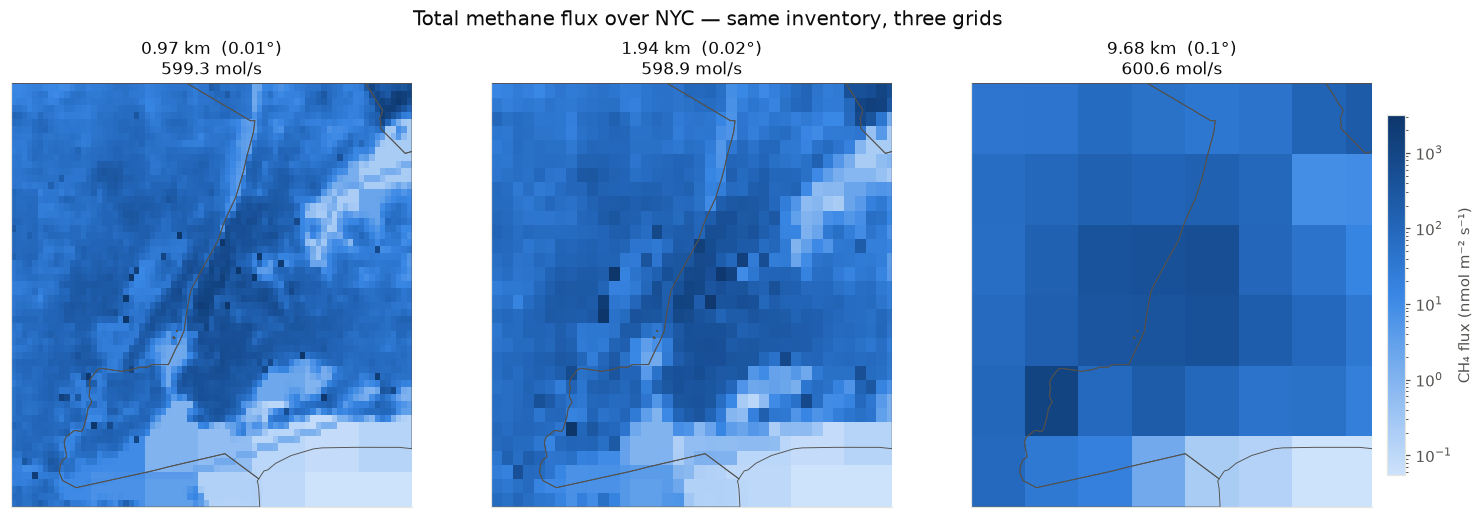

In [7]:
SECTORS = res_runs[0.02]["ctx"].shared["sectors_run"]


def sector_total(r):
    da = sum(r[s].fillna(0) for s in SECTORS)
    da = da.where(np.isfinite(r[SECTORS[0]]))   # keep the domain mask
    return da


fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)

grids = {r: sector_total(res_runs[r]) for r in RESOLUTIONS}
finite = np.concatenate([g.values[np.isfinite(g.values) & (g.values > 0)].ravel()
                         for g in grids.values()])
vmin, vmax = np.percentile(finite, 2), np.percentile(finite, 99.8)
norm = LogNorm(vmin=vmin, vmax=vmax)

for ax, (r, g) in zip(axes, grids.items()):
    xmin, ymin, xmax, ymax = geo.ext(g)
    im = ax.imshow(g.values, extent=(xmin, xmax, ymin, ymax), origin="upper",
                   cmap=FLUX_CMAP, norm=norm, interpolation="nearest")
    domain_states.boundary.plot(ax=ax, color=INK_MUTED, linewidth=0.6)
    ax.set_xlim(NYC_BBOX[0], NYC_BBOX[2]); ax.set_ylim(NYC_BBOX[1], NYC_BBOX[3])
    mass = total_mass(g, res_runs[r]["template"])
    ax.set_title(f"{RESOLUTIONS[r]:.2f} km  ({r}°)\n{mass:.1f} mol/s", color=INK)
    ax.set_xticks([]); ax.set_yticks([])

cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
cb.set_label("CH₄ flux (nmol m⁻² s⁻¹)", color=INK_MUTED)
fig.suptitle("Total methane flux over NYC — same inventory, three grids",
             color=INK, fontsize=13)
plt.show()

### Is mass actually conserved across resolutions?

In [8]:
rows = []
for r in RESOLUTIONS:
    row = {"cell (km)": round(RESOLUTIONS[r], 2)}
    for s in SECTORS:
        row[s] = total_mass(res_runs[r][s], res_runs[r]["template"])
    row["TOTAL"] = sum(row[s] for s in SECTORS)
    rows.append(row)

mass_table = pd.DataFrame(rows).set_index("cell (km)")
drift = 100 * (mass_table["TOTAL"].max() - mass_table["TOTAL"].min()) / mass_table["TOTAL"].mean()
print(f"total mass spread across the three grids: {drift:.2f}%\n")
mass_table.round(3)

total mass spread across the three grids: 0.27%



,landfills,natural_gas_distribution,natural_gas_transmission,stationary_combustion,wastewater,wetlands,remaining_gepa,TOTAL
cell (km),,,,,,,,
0.97,133.687,344.421,2.689,16.895,62.311,17.810,21.491,599.303
1.94,133.687,344.969,2.697,17.364,62.317,16.364,21.549,598.946
9.68,133.687,344.982,2.646,17.385,62.297,17.774,21.785,600.555


## 2. Wetlands: Wetcharts vs SOCCR1 vs SOCCR2

Two genuinely different estimates of the same thing. **Wetcharts** is an ensemble
of process models. **SOCCR** multiplies NWI wetland cover by an emission factor —
SOCCR1 uses one national factor per wetland class, SOCCR2 varies the coastal
classes by which ocean basin the water drains to. Freshwater (lakes/rivers) is
added to all three.

In [9]:
WETLAND_VARIANTS = {
    "Wetcharts": dict(Use_Wetcharts=True, Use_SOCCR1=False, Use_SOCCR2=False),
    "SOCCR1": dict(Use_Wetcharts=False, Use_SOCCR1=True, Use_SOCCR2=False),
    "SOCCR2": dict(Use_Wetcharts=False, Use_SOCCR1=False, Use_SOCCR2=True),
}

wet_runs = {}
for name, opts in WETLAND_VARIANTS.items():
    cfg = base_config()
    for k in ("Process_landfills", "Process_natural_gas_distribution",
              "Process_natural_gas_transmission", "Process_wastewater",
              "Process_stationary_combustion", "Process_remaining_sectors_from_gridded_EPA"):
        setattr(cfg, k, False)          # wetlands only, to keep this quick
    for k, v in opts.items():
        setattr(cfg, k, v)
    wet_runs[name] = run(f"wet_{name}", 0.02, cfg)
    print(f"{name:10s} {wet_runs[name]['seconds']:5.1f}s")

Running sector: Wetlands & inland waters


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/wet_Wetcharts/out/M3T_total.nc
Wetcharts    4.1s
Running sector: Wetlands & inland waters


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/wet_SOCCR1/out/M3T_total.nc
SOCCR1       1.4s


Running sector: Wetlands & inland waters


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/wet_SOCCR2/out/M3T_total.nc
SOCCR2       2.0s


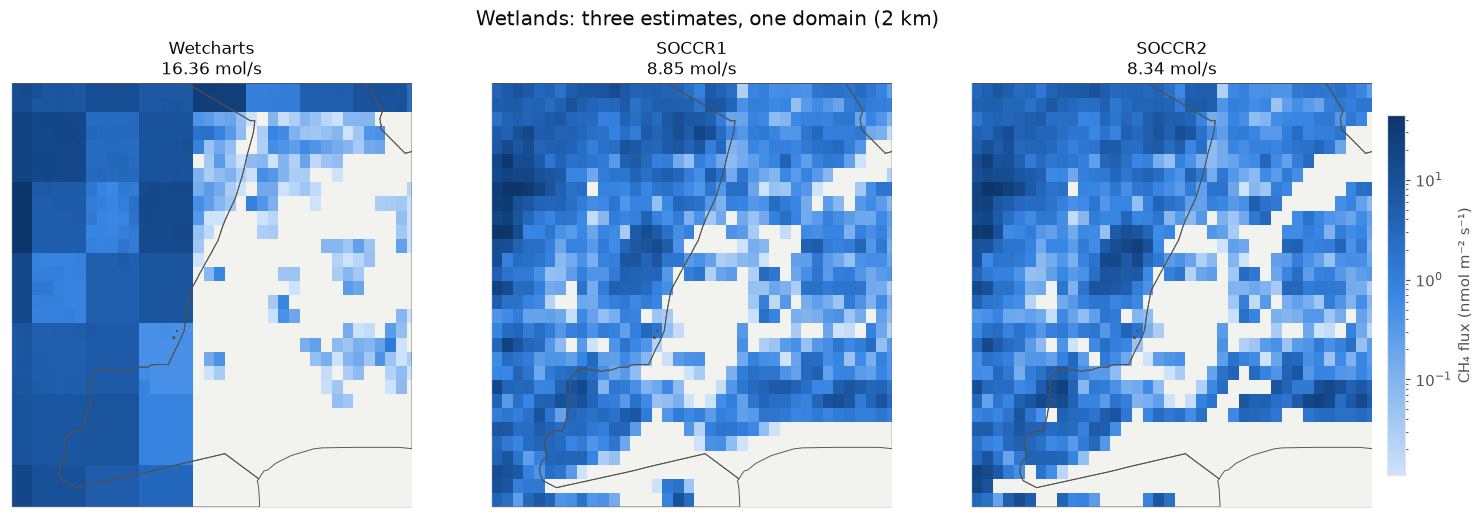

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)

wet_grids = {n: r["wetlands"] for n, r in wet_runs.items()}
f = np.concatenate([g.values[np.isfinite(g.values) & (g.values > 0)].ravel()
                    for g in wet_grids.values()])
norm = LogNorm(vmin=np.percentile(f, 2), vmax=np.percentile(f, 99.8))

for ax, (name, g) in zip(axes, wet_grids.items()):
    xmin, ymin, xmax, ymax = geo.ext(g)
    im = ax.imshow(g.values, extent=(xmin, xmax, ymin, ymax), origin="upper",
                   cmap=FLUX_CMAP, norm=norm, interpolation="nearest")
    domain_states.boundary.plot(ax=ax, color=INK_MUTED, linewidth=0.6)
    ax.set_xlim(NYC_BBOX[0], NYC_BBOX[2]); ax.set_ylim(NYC_BBOX[1], NYC_BBOX[3])
    mass = total_mass(g, wet_runs[name]["template"])
    ax.set_title(f"{name}\n{mass:.2f} mol/s", color=INK)
    ax.set_xticks([]); ax.set_yticks([])

cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
cb.set_label("CH₄ flux (nmol m⁻² s⁻¹)", color=INK_MUTED)
fig.suptitle("Wetlands: three estimates, one domain (2 km)", color=INK, fontsize=13)
plt.show()

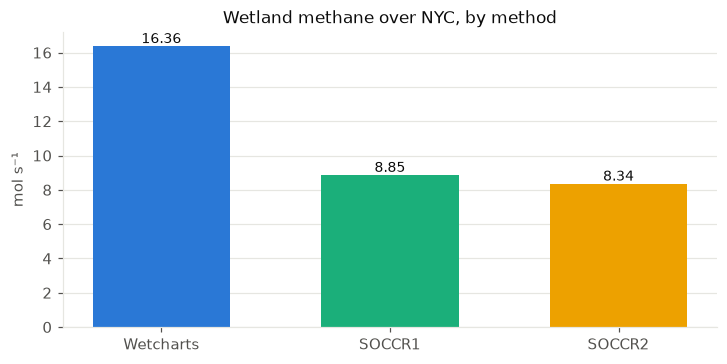

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.2), constrained_layout=True)
names = list(wet_runs)
vals = [total_mass(wet_runs[n]["wetlands"], wet_runs[n]["template"]) for n in names]
bars = ax.bar(names, vals, color=SERIES[: len(names)], width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom",
            color=INK, fontsize=9)
ax.set_ylabel("mol s⁻¹", color=INK_MUTED)
ax.set_title("Wetland methane over NYC, by method", color=INK)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

## 3. Disaggregation: which CO₂ proxy, and at what scale

Stationary combustion knows how much methane each **county** emits, but not where
inside it. It borrows the spatial pattern of a gridded CO₂ inventory — **Vulcan**
or **ACES**. Separately, `by_state` splits each state's total across its counties,
while `by_domain` splits one national total using national CO shares.

The proxy should move the *pattern* but not the *total*; the level should move both.

In [12]:
DISAGG_VARIANTS = {
    "Vulcan · by_state":  dict(Use_Vulcan=True,  Use_ACES=False,
                               stationary_combustion_by_state=True,
                               stationary_combustion_by_domain=False),
    "ACES · by_state":    dict(Use_Vulcan=False, Use_ACES=True,
                               stationary_combustion_by_state=True,
                               stationary_combustion_by_domain=False),
    "Vulcan · by_domain": dict(Use_Vulcan=True,  Use_ACES=False,
                               stationary_combustion_by_state=False,
                               stationary_combustion_by_domain=True),
}

dis_runs = {}
for name, opts in DISAGG_VARIANTS.items():
    cfg = base_config()
    for k in ("Process_landfills", "Process_natural_gas_distribution",
              "Process_natural_gas_transmission", "Process_wastewater",
              "Process_wetlands_and_inland_waters",
              "Process_remaining_sectors_from_gridded_EPA"):
        setattr(cfg, k, False)          # stationary combustion only
    for k, v in opts.items():
        setattr(cfg, k, v)
    dis_runs[name] = run(f"dis_{name.replace(' · ', '_')}", 0.02, cfg)
    print(f"{name:20s} {dis_runs[name]['seconds']:5.1f}s")

NEI is every 3 years and does not have an inventory for 2019. Using 2020 as the nearest available data.
Running sector: Stationary combustion


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/dis_Vulcan_by_state/out/M3T_total.nc
Vulcan · by_state      2.1s


NEI is every 3 years and does not have an inventory for 2019. Using 2020 as the nearest available data.
Running sector: Stationary combustion


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/dis_ACES_by_state/out/M3T_total.nc
ACES · by_state        1.2s
NEI is every 3 years and does not have an inventory for 2019. Using 2020 as the nearest available data.
Running sector: Stationary combustion


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/dis_Vulcan_by_domain/out/M3T_total.nc
Vulcan · by_domain     0.9s


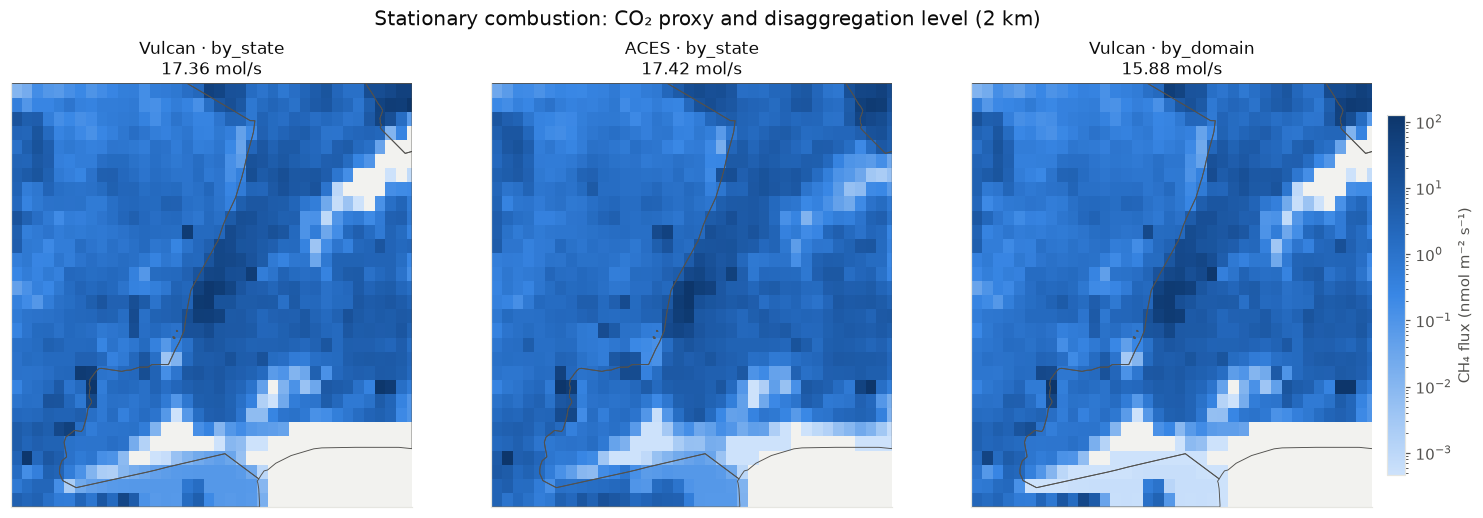

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)

dis_grids = {n: r["stationary_combustion"] for n, r in dis_runs.items()}
f = np.concatenate([g.values[np.isfinite(g.values) & (g.values > 0)].ravel()
                    for g in dis_grids.values()])
norm = LogNorm(vmin=np.percentile(f, 2), vmax=np.percentile(f, 99.8))

for ax, (name, g) in zip(axes, dis_grids.items()):
    xmin, ymin, xmax, ymax = geo.ext(g)
    im = ax.imshow(g.values, extent=(xmin, xmax, ymin, ymax), origin="upper",
                   cmap=FLUX_CMAP, norm=norm, interpolation="nearest")
    domain_states.boundary.plot(ax=ax, color=INK_MUTED, linewidth=0.6)
    ax.set_xlim(NYC_BBOX[0], NYC_BBOX[2]); ax.set_ylim(NYC_BBOX[1], NYC_BBOX[3])
    mass = total_mass(g, dis_runs[name]["template"])
    ax.set_title(f"{name}\n{mass:.2f} mol/s", color=INK)
    ax.set_xticks([]); ax.set_yticks([])

cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
cb.set_label("CH₄ flux (nmol m⁻² s⁻¹)", color=INK_MUTED)
fig.suptitle("Stationary combustion: CO₂ proxy and disaggregation level (2 km)",
             color=INK, fontsize=13)
plt.show()

## 4. Mass conservation

`Mass_conserving_regrid` (default **True**) redistributes the disaggregated mass
conservatively, then divides by each cell's true geodesic area.

The R does neither: it treats a 1 km Vulcan/ACES pixel as exactly 1 km² — those
grids are Lambert Conformal Conic, *conformal, not equal-area* — and then
area-averages the flux and weights cells by their coverage of the domain's
bounding box. The result is inflated by ~1.4%. Setting the flag to False
reproduces R exactly, which is what the golden tests pin.

In [14]:
mc_runs = {}
for label, flag in [("conserving (default)", True), ("R-compatible", False)]:
    cfg = base_config()
    for k in ("Process_landfills", "Process_natural_gas_transmission",
              "Process_wastewater", "Process_wetlands_and_inland_waters",
              "Process_remaining_sectors_from_gridded_EPA"):
        setattr(cfg, k, False)   # the two CO2-disaggregated sectors
    cfg.Mass_conserving_regrid = flag
    mc_runs[label] = run(f"mc_{flag}", 0.02, cfg)

sectors_mc = ["stationary_combustion", "natural_gas_distribution"]
rows = []
for label, r in mc_runs.items():
    row = {"gridding": label}
    for s in sectors_mc:
        row[s] = total_mass(r[s], r["template"])
    rows.append(row)
mc = pd.DataFrame(rows).set_index("gridding")
mc["TOTAL"] = mc.sum(axis=1)
mc.loc["difference (%)"] = 100 * (mc.loc["R-compatible"] / mc.loc["conserving (default)"] - 1)
mc.round(4)

NEI is every 3 years and does not have an inventory for 2019. Using 2020 as the nearest available data.
Running sector: Natural gas distribution


Running sector: Stationary combustion


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/mc_True/out/M3T_total.nc


NEI is every 3 years and does not have an inventory for 2019. Using 2020 as the nearest available data.
Running sector: Natural gas distribution


Running sector: Stationary combustion


Combined total written to /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/M3T/python/notebooks/nb_runs/mc_False/out/M3T_total.nc


,stationary_combustion,natural_gas_distribution,TOTAL
gridding,,,
conserving (default),17.3642,344.9690,362.3332
R-compatible,17.8006,348.6529,366.4535
difference (%),2.5130,1.0679,1.1372


The R-compatible path carries a few percent more methane than the counties
actually handed it — the same emissions, gridded onto the same cells, but the
books no longer balance. That bias is latitude-dependent (the conformal scale
factor varies across CONUS), so it is not a constant you can divide out.

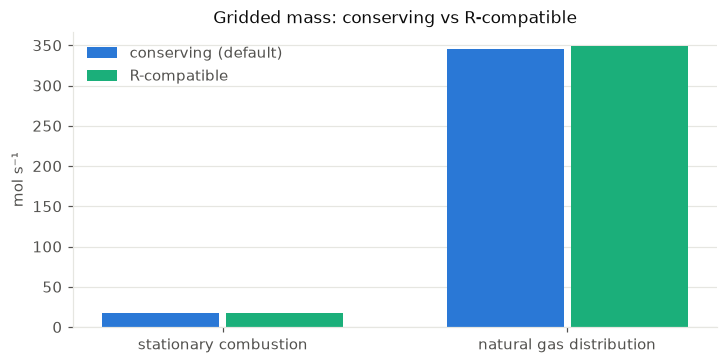

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 3.2), constrained_layout=True)
labels = list(mc_runs)
x = np.arange(len(sectors_mc))
w = 0.36
for i, label in enumerate(labels):
    vals = [mc.loc[label, s] for s in sectors_mc]
    ax.bar(x + (i - 0.5) * w, vals, width=w - 0.02, label=label, color=SERIES[i])
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in sectors_mc])
ax.set_ylabel("mol s⁻¹", color=INK_MUTED)
ax.set_title("Gridded mass: conserving vs R-compatible", color=INK)
ax.legend(frameon=False, labelcolor=INK_MUTED)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

## Sector breakdown

Where the methane over NYC actually comes from, at 2 km.

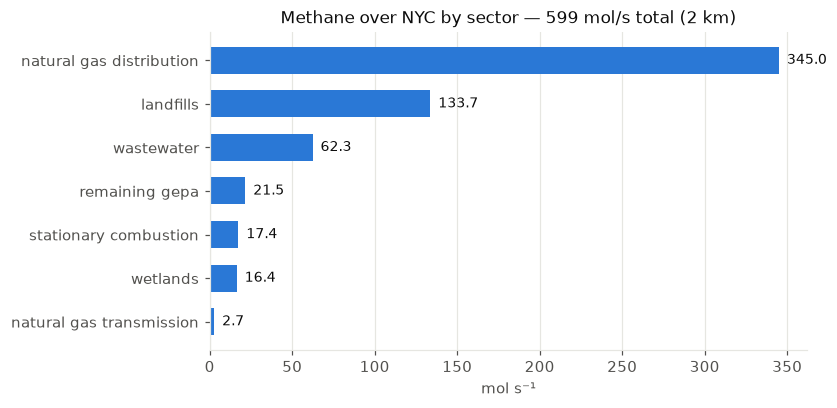

In [16]:
r = res_runs[0.02]
totals = pd.Series(
    {s: total_mass(r[s], r["template"]) for s in SECTORS}
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7.5, 3.6), constrained_layout=True)
bars = ax.barh([s.replace("_", " ") for s in totals.index], totals.values,
               color=SERIES[0], height=0.62)
for b, v in zip(bars, totals.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f"  {v:.1f}", va="center",
            color=INK, fontsize=9)
ax.set_xlabel("mol s⁻¹", color=INK_MUTED)
ax.set_title(f"Methane over NYC by sector — {totals.sum():.0f} mol/s total (2 km)",
             color=INK)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.show()